In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [5]:
df = data

In [6]:
df.shape

(535, 196)

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [8]:
data.iloc[:,-3] == 1 

0      False
1      False
2      False
3      False
4      False
       ...  
530     True
531     True
532     True
533     True
534     True
Name: gender, Length: 535, dtype: bool

In [13]:
X = df.iloc[:, :40].copy()
y = df.iloc[:,-2].copy()

In [14]:
X

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,3.571719,3.791596,0.273689,1.043244,1.650352,0.314641,1.062270,3.434106,0.121581,4.740209
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,0.879277,-1.884373,0.209843,-0.885930,-2.989875,-0.209330,-3.103334,-0.466195,-2.218545,-1.445988
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,6.345162,0.300393,1.122728,1.067898,0.311053,5.436693,3.956986,4.741616,1.423591,-0.730692
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,7.308569,4.347467,3.764071,1.434620,-0.259375,3.903956,0.931435,4.396825,0.732828,0.685493
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,-0.051422,-1.986323,-3.419830,0.936246,-3.025292,-1.398108,-2.840177,-1.987542,-1.657225,-2.034080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,-1.823846,-1.956523,0.294094,1.669532,2.200643,3.741535,1.756464,2.903389,-2.047863,0.830420
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,5.822308,6.702266,5.935998,11.099479,9.776107,9.439350,6.585461,4.854636,2.974486,2.546776
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,1.098509,0.147318,-2.007021,0.693413,0.610932,1.944821,2.337294,3.724216,4.159209,5.482543
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,5.389098,0.107034,0.381191,2.807357,0.879433,0.842138,1.456466,1.559664,0.658600,2.135692


In [15]:
y

0      6
1      3
2      1
3      6
4      3
      ..
530    2
531    7
532    7
533    1
534    1
Name: emo, Length: 535, dtype: int64

In [16]:
X.shape, y.shape

((535, 40), (535,))

In [17]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_encoded = lb.fit_transform(y)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [19]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


svm_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.6542056074766355
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.92      0.75        26
           1       0.67      0.50      0.57        16
           2       0.71      0.75      0.73        16
           3       0.71      0.56      0.62         9
           4       0.73      0.57      0.64        14
           5       0.17      0.07      0.10        14
           6       0.75      1.00      0.86        12

    accuracy                           0.65       107
   macro avg       0.62      0.62      0.61       107
weighted avg       0.62      0.65      0.62       107

SVM Confusion Matrix:
 [[24  0  0  0  1  1  0]
 [ 0  8  5  0  0  0  3]
 [ 0  3 12  1  0  0  0]
 [ 1  0  0  5  1  2  0]
 [ 2  1  0  0  8  2  1]
 [11  0  0  1  1  1  0]
 [ 0  0  0  0  0  0 12]]


In [24]:
import seaborn as sns

def plot_cm(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # row-wise percentage
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=classes, yticklabels=classes)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(title)
    plt.show()

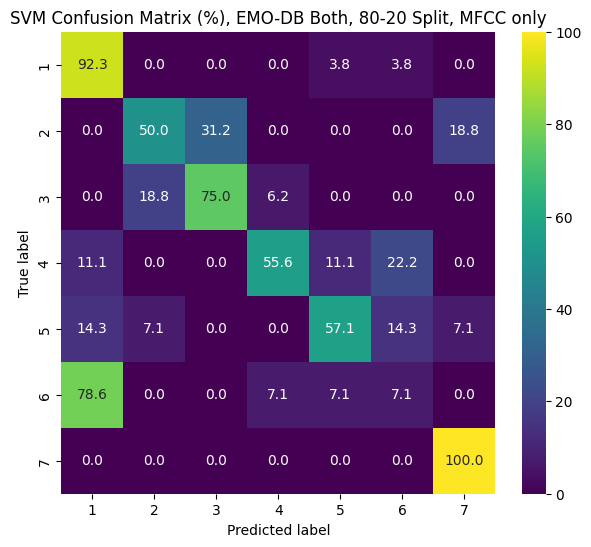

In [30]:
class_names = lb.classes_
plot_cm(y_test, y_pred_svm, class_names, title='SVM Confusion Matrix (%), EMO-DB Both, 80-20 Split, MFCC only')

In [20]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=42
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Classification Report:\n", classification_report(y_test, y_pred_rf))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.6728971962616822
RF Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.92      0.69        26
           1       0.80      0.75      0.77        16
           2       0.72      0.81      0.76        16
           3       0.86      0.67      0.75         9
           4       0.62      0.36      0.45        14
           5       0.25      0.07      0.11        14
           6       1.00      0.92      0.96        12

    accuracy                           0.67       107
   macro avg       0.69      0.64      0.64       107
weighted avg       0.66      0.67      0.64       107

RF Confusion Matrix:
 [[24  0  0  0  1  1  0]
 [ 0 12  3  0  0  1  0]
 [ 1  1 13  0  1  0  0]
 [ 2  0  0  6  1  0  0]
 [ 5  2  1  0  5  1  0]
 [12  0  0  1  0  1  0]
 [ 0  0  1  0  0  0 11]]


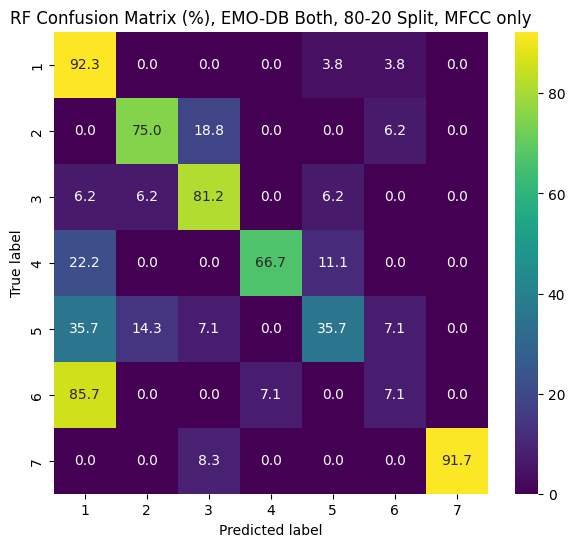

In [29]:
plot_cm(y_test, y_pred_rf, class_names, title='RF Confusion Matrix (%), EMO-DB Both, 80-20 Split, MFCC only')